In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
# Load image (GRAYSCALE)

img = Image.open('images/panda.jpeg').convert('L').resize((256, 256))
imgMat = np.array(img, dtype=np.float32)


In [4]:
# (b) Add Gaussian Noise

mean = 0
var = 0.01
sigma = var ** 0.5

gaussian_noise = np.random.normal(mean, sigma, imgMat.shape) #Generate noise with the same shape as your image
noisy_gaussian = imgMat + gaussian_noise * 255

noisy_gaussian = np.clip(noisy_gaussian, 0, 255)#Clip to valid pixel boundaries and cast back to uint8

In [5]:
# (c) Low-pass filter (Box filter)

def box_filter(mat, n=1): #n=1 _3*3 filter
    h, w = mat.shape #Retrieves the height (h) and width (w) of your input noisy image matrix.
    out = np.zeros_like(mat) #Creates a completely black canvas (filled with zeros) of the exact same dimensions and data type to store the filtered, smoothed output image.

    for i in range(h): #starting from the top-left corner and ending at the bottom-right.
        for j in range(w):
            total = 0
            count = 0

            for dx in range(-n, n+1): #n=1 establishes a radius. range(-1, 2) generates indices [-1, 0, 1].
                for dy in range(-n, n+1):
                    x, y = i+dx, j+dy #getting neighbor
                    if 0 <= x < h and 0 <= y < w: #handles the image edges.
                        total += mat[x][y] 
                        count += 1

            out[i][j] = total / count

    return out

low_pass = box_filter(noisy_gaussian, n=1)

Original vs Noisy vs Low-pass ready


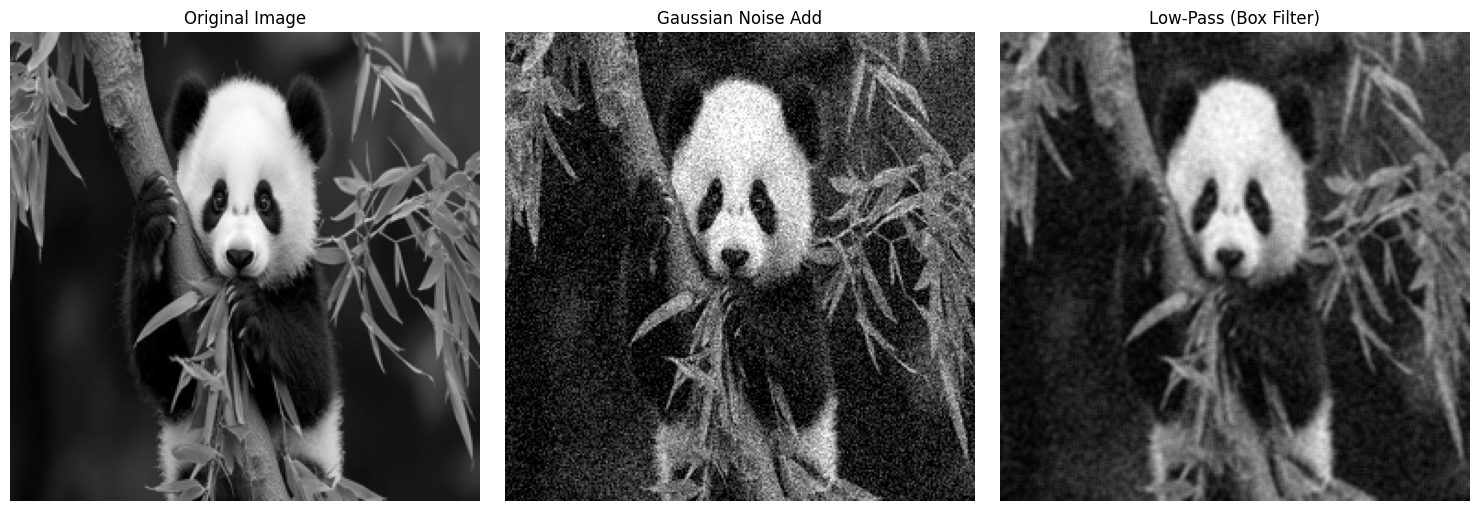

In [6]:
# (d) Display effect (comparison)
print("Original vs Noisy vs Low-pass ready")
import matplotlib.pyplot as plt
import numpy as np

imgMat_display = imgMat.astype(np.uint8)
noisy_display = noisy_gaussian.astype(np.uint8)
low_pass_display = low_pass.astype(np.uint8)

# Creates a figure window with 1 row and 3 columns of subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(imgMat_display, cmap='gray')
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')  # Hide pixel coordinate axes

axes[1].imshow(noisy_display, cmap='gray')
axes[1].set_title('Gaussian Noise Add', fontsize=12)
axes[1].axis('off')

axes[2].imshow(low_pass_display, cmap='gray')
axes[2].set_title('Low-Pass (Box Filter)', fontsize=12)
axes[2].axis('off')

plt.tight_layout()  # Adjusts spacing perfectly
plt.show()

In [ ]:
# (e) Add Salt & Pepper Noise

def salt_pepper(img, density=0.05):
    out = img.copy()
    h, w = out.shape #h*w= total no of pixel, density=0.05, 5% of total pixel will be changed to salt and pepper noise
    #func runs twice so impacts roughly 5% + 5% = 10% of the image.
    num_pixels = int(density * h * w)

    # salt (white)
    coords = [np.random.randint(0, i, num_pixels) for i in (h, w)] 
    out[coords[0], coords[1]] = 255

    # pepper (black)
    coords = [np.random.randint(0, i, num_pixels) for i in (h, w)]
    out[coords[0], coords[1]] = 0

    return out

sp_noisy = salt_pepper(imgMat, density=0.05)

In [8]:
# (f) Remove Salt & Pepper noise using Median filter

def median_filter(mat, n=1):
    h, w = mat.shape
    out = np.zeros_like(mat)

    for i in range(h):
        for j in range(w):
            window = []

            for dx in range(-n, n+1):
                for dy in range(-n, n+1):
                    x, y = i+dx, j+dy
                    if 0 <= x < h and 0 <= y < w:
                        window.append(mat[x][y])

            out[i][j] = np.median(window)

    return out

median_filtered = median_filter(sp_noisy, n=1)


In [ ]:
# (g) High-pass filter (Edge enhancement)

def high_pass(mat):
    blurred = box_filter(mat, n=1)
    hp = mat - blurred
    #Flat areas (0) become 128 (neutral gray).Positive edges become brighter than gray (128 + 50 = 178).Negative edges become darker than gray (128 - 50 = 78).
    #np.clip(..., 0, 255) acts as a safety guardrail. It forces any value below 0 to become 0, and any value above 255 to become 255, keeping the matrix safe for image rendering.
    return np.clip(hp + 128, 0, 255)  # shift for visibility

high_pass_img = high_pass(imgMat)


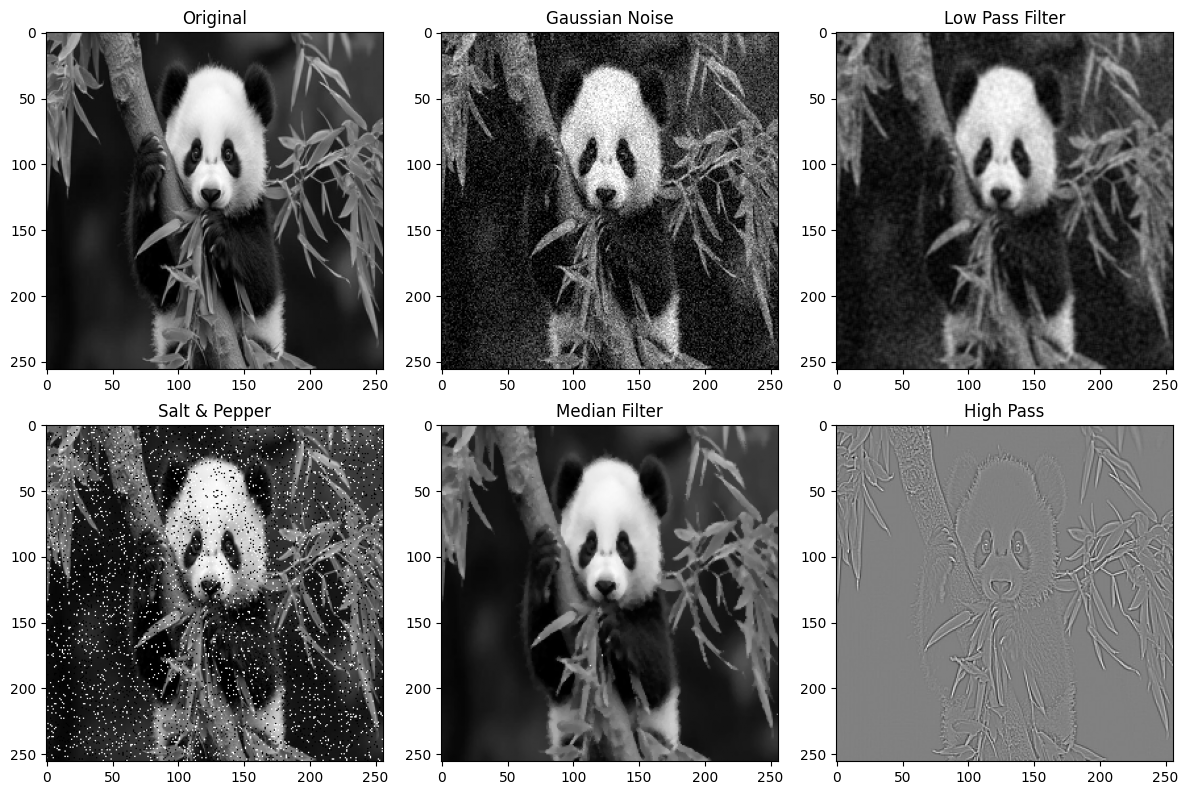

In [ ]:
# Show results

plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)#2 rows and 3 columns of plots (6 total slots),
plt.title("Original")
plt.imshow(imgMat, cmap='gray')

plt.subplot(2,3,2)
plt.title("Gaussian Noise")
plt.imshow(noisy_gaussian, cmap='gray')

plt.subplot(2,3,3)
plt.title("Low Pass Filter")
plt.imshow(low_pass, cmap='gray')

plt.subplot(2,3,4)
plt.title("Salt & Pepper")
plt.imshow(sp_noisy, cmap='gray')

plt.subplot(2,3,5)
plt.title("Median Filter")
plt.imshow(median_filtered, cmap='gray')

plt.subplot(2,3,6)
plt.title("High Pass")
plt.imshow(high_pass_img, cmap='gray')

plt.tight_layout()
plt.show()